In [3]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from hloc import extract_features, match_features, reconstruction, visualization, pairs_from_exhaustive
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d

In [4]:
images = Path('datasets')
outputs = Path('outputs/sift/')
!rm -rf $outputs
sfm_pairs = outputs / 'pairs-sfm.txt'
# loc_pairs = outputs / 'pairs-loc.txt'
sfm_dir = outputs / 'sfm'
features = outputs / 'features.h5'
matches = outputs / 'matches.h5'

# feature_conf = extract_features.confs['disk']
# matcher_conf = match_features.confs['disk+lightglue']
# matcher_conf = match_features.confs['superglue']

feature_conf = extract_features.confs['sift']
matcher_conf = match_features.confs['NN-ratio']


3 mapping images


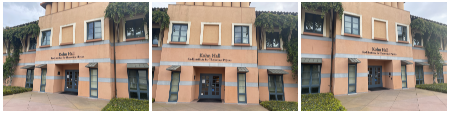

In [5]:
references = [str(p.relative_to(images)) for p in (images).iterdir()]
print(len(references), "mapping images")
plot_images([read_image(images / r) for r in references], dpi=25)

In [6]:
extract_features.main(feature_conf, images, image_list=references, feature_path=features)
pairs_from_exhaustive.main(sfm_pairs, image_list=references)
match_features.main(matcher_conf, sfm_pairs, features=features, matches=matches)

[2025/04/25 00:06:08 hloc INFO] Extracting local features with configuration:
{'model': {'name': 'dog'},
 'output': 'feats-sift',
 'preprocessing': {'grayscale': True, 'resize_max': 1600}}
100%|██████████| 3/3 [00:05<00:00,  1.93s/it]
[2025/04/25 00:06:16 hloc INFO] Finished exporting features.
[2025/04/25 00:06:16 hloc INFO] Found 3 pairs.
[2025/04/25 00:06:16 hloc INFO] Matching local features with configuration:
{'model': {'do_mutual_check': True,
           'name': 'nearest_neighbor',
           'ratio_threshold': 0.8},
 'output': 'matches-NN-mutual-ratio.8'}
100%|██████████| 3/3 [00:06<00:00,  2.30s/it]
[2025/04/25 00:06:23 hloc INFO] Finished exporting matches.


WindowsPath('outputs/sift/matches.h5')

In [4]:
import cv2
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def load_image(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def load_features(features_h5, key):
    with h5py.File(features_h5, 'r') as f_feat:
        kpts = [None] * len(key)
        for i,k in enumerate(key):
            if k in f_feat:
                kpts[i] = f_feat[k]['keypoints'][:]
            else:
                raise KeyError(f"Key '{k}' not found in {features_h5}")
    return kpts

def load_matches(matches_h5, key1, key2):
    with h5py.File(matches_h5, 'r') as f_match:
        if key1 in f_match and key2 in f_match[key1]:
            matches = f_match[key1][key2]['matches0'][:]
        elif key2 in f_match and key1 in f_match[key2]:
            matches = f_match[key2][key1]['matches0'][:]
        else:
            raise KeyError(f"No matches found for '{key1}' and '{key2}'")
    return matches


def visualize_keypoints(image_path, h5_file, key):
    img = load_image(image_path)
    keypoints = load_features(h5_file, [key])[0]
    for (x, y) in keypoints:
        cv2.circle(img, (int(x), int(y)), 10, (0, 255, 0), -1)
    plt.figure(figsize=(8, 6))
    plt.title(f"Keypoints: {key}")
    plt.imshow(img)
    plt.axis('off')
    plt.show()


def visualize_matches(image_path1, image_path2, key1, key2, features_h5, matches_h5):
    img1 = load_image(image_path1)
    img2 = load_image(image_path2)

    kpts1, kpts2 = load_features(features_h5, [key1, key2])

    matches = load_matches(matches_h5, key1, key2)

    valid = matches > -1
    matched_kpts1 = kpts1[valid]
    matched_kpts2 = kpts2[matches[valid]]

    # Combine two images side by side
    height = max(img1.shape[0], img2.shape[0])
    combo = np.zeros((height, img1.shape[1] + img2.shape[1], 3), dtype=np.uint8)
    combo[:img1.shape[0], :img1.shape[1]] = img1
    combo[:img2.shape[0], img1.shape[1]:] = img2

    for pt1, pt2 in zip(matched_kpts1, matched_kpts2):
        pt1 = tuple(np.round(pt1).astype(int))
        pt2 = tuple(np.round(pt2).astype(int) + np.array([img1.shape[1], 0]))
        cv2.line(combo, pt1, pt2, (255, 0, 0), 3)

    plt.figure(figsize=(12, 6))
    plt.title(f"Matches: {key1} ↔ {key2} ({len(matched_kpts1)} matches)")
    plt.imshow(combo)
    plt.axis('off')
    plt.show()


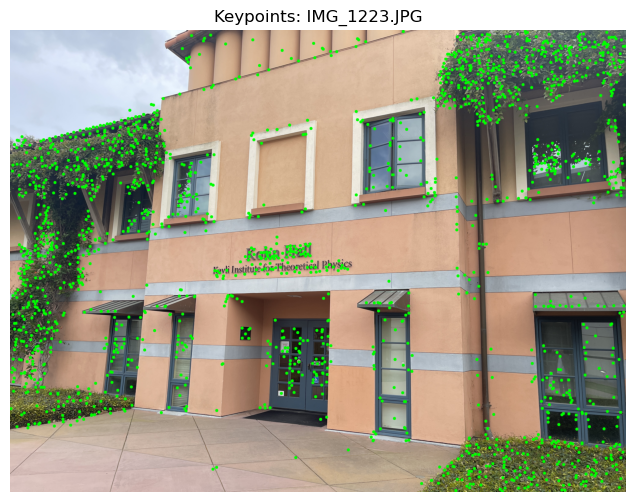

(178, 2) (178, 2)


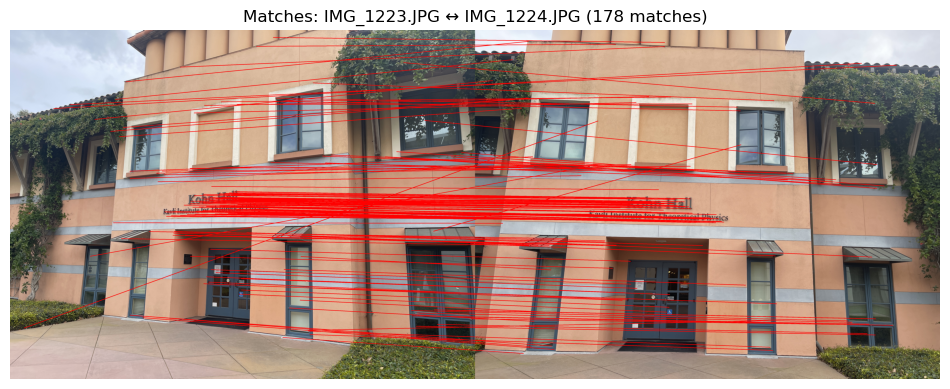

In [31]:
images_dir = Path("datasets")
features_path = str(features)
matches_path = str(matches)

key1 = "IMG_1223.JPG"
key2 = "IMG_1224.JPG"

img1_path = images_dir / key1
img2_path = images_dir / key2

# 可视化关键点
visualize_keypoints(img1_path, features_path, key1)

# 可视化匹配点
visualize_matches(img1_path, img2_path, key1, key2, features_path, matches_path)


In [14]:
import import_ipynb
import m1

key1 = "IMG_1223.JPG"
key2 = "IMG_1224.JPG"
features_path = "outputs/sift/features.h5"
matches_path = "outputs/sift/matches.h5"

img_1 = load_image("datasets\IMG_1223.JPG")
img_2 = load_image("datasets\IMG_1224.JPG")

kpts1, kpts2 = load_features(features_path, [key1, key2])
matches = load_matches(matches_path, key1, key2)

valid = matches > -1
matched_kpts1 = kpts1[valid]
matched_kpts2 = kpts2[matches[valid]]


In [18]:
print(matched_kpts1[:4], matched_kpts2[:4])

[[1477.   320.8]
 [2308.   590.5]
 [2308.   590.5]
 [ 522.5  646. ]] [[1644.   143. ]
 [2274.   667.5]
 [2274.   667.5]
 [3654.   305. ]]


In [ ]:
H_12 = m1.compute_homography_dlt_normalized(matched_kpts1, matched_kpts2)
print(H_12)

LinAlgError: Singular matrix